# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### О задании

В этой работе:

1. Использую решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, визуализирую разделяющие поверхности и разбираюсь с переобучением.

2. Реализую своё решающее дерево для задачи классификации и сравниваю его со стандартной имплементацией.

3. Исследую влияние бэггинга на смещение и разброс.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Решающие деревья

### Визуализация

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

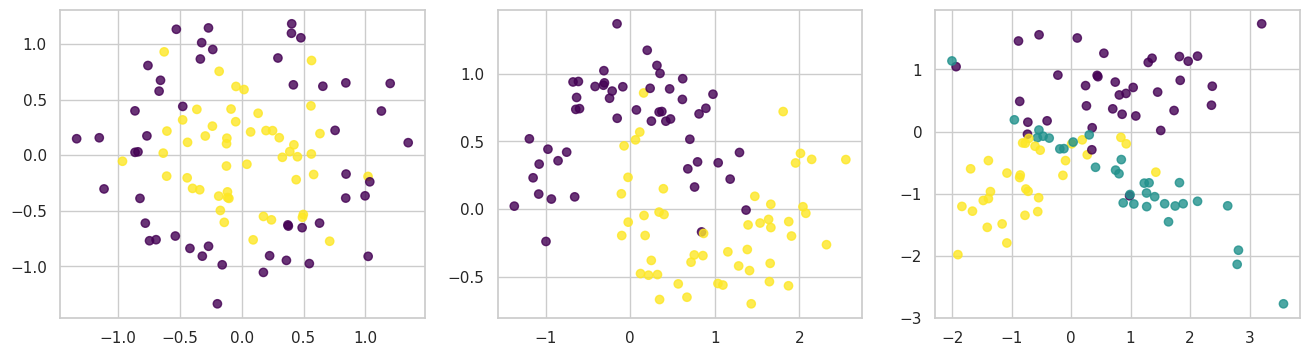

In [3]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

Для каждого датасета обучаю решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Строю разделяющие поверхности и считаю accuracy на обучающей и тестовой выборках, комментирую, в каких случаях и почему модель переобучается.

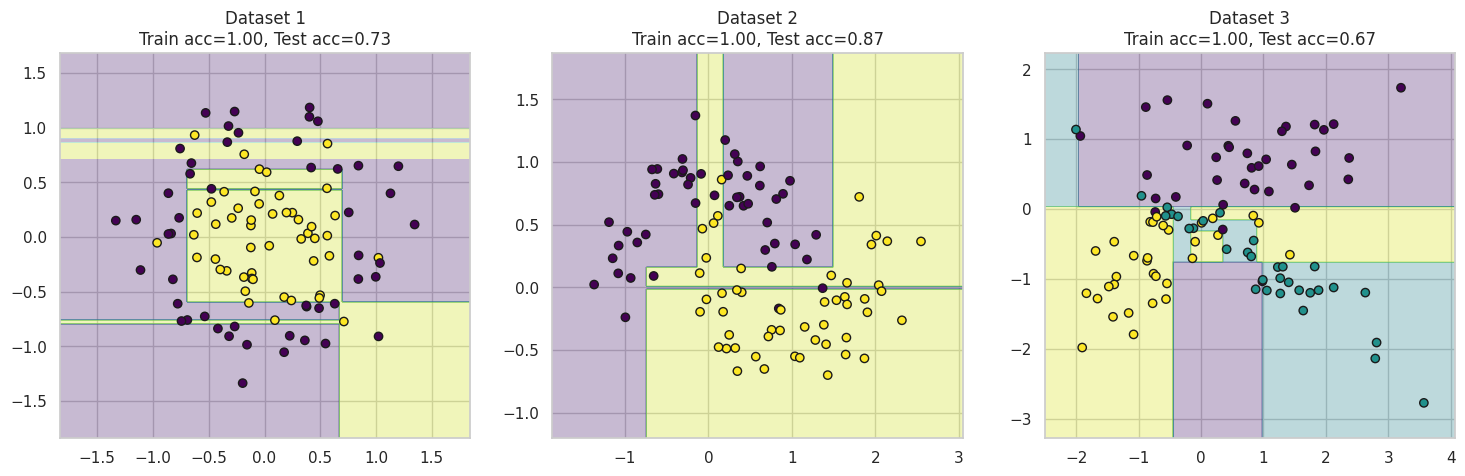

In [4]:
def plot_decision_boundary(model, X, y, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap="viridis", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")



plt.figure(figsize=(18, 5))

for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test, y_test)

    ax = plt.subplot(1, 3, i + 1)
    plot_decision_boundary(clf, X, y, ax)
    ax.set_title(f"Dataset {i+1}\nTrain acc={train_acc:.2f}, Test acc={test_acc:.2f}")

plt.show()

На 1 датасете сильное переобучение, видим много узких прямоугольных областей, в каждой из которых по паре точек. То есть дерево пытается обогнуть каждую точку, чтобы объяснить шум.

На 2 датасете переобучение меньше, видим одну супер узкую область. Дерево всё ещё запоминает отдельные ступенчатые изломы.

На 3 датасете из-за того, что класса 3 образуются многочисленные узкие прямоугольники, переобучение еще больше, чем в первом. Модель пытается идеально разделить классы на трейне, игнорируя то, что структуры пересекаются и имеют шум.

Выбираю один датасет из предыдущего задания и исследую на его примере влияние на итоговое качество двух гиперпараметров одновременно. Для каждой пары значений считаю accuracy на обучающей и тестовой выборках и сохраняю результаты в таблицу.

Визуализирую зависимость качества на тестовой выборке от значений выбранных гиперпараметров, смотрю, при каких значениях наблюдается лучшее соотношение разброса и смещения.

выбрал второй датасет.

In [5]:
X, y = datasets[1]

max_depth_values = [1, 2, 3, 4, 5, 7, 10, None]
min_split_values = [2, 4, 6, 10, 20, 40]

results = []

for depth in max_depth_values:
    for min_split in min_split_values:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=42
        )
        model.fit(X_train, y_train)

        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)

        results.append([depth, min_split, train_acc, test_acc])

df = pd.DataFrame(results, columns=["max_depth", "min_samples_split",
                                    "train_acc", "test_acc"])
df

,max_depth,min_samples_split,train_acc,test_acc
0,1.0,2,0.842857,0.800000
1,1.0,4,0.842857,0.800000
2,1.0,6,0.842857,0.800000
3,1.0,10,0.842857,0.800000
4,1.0,20,0.842857,0.800000
5,1.0,40,0.842857,0.800000
6,2.0,2,0.914286,0.933333
7,2.0,4,0.914286,0.933333
8,2.0,6,0.914286,0.933333
9,2.0,10,0.914286,0.933333


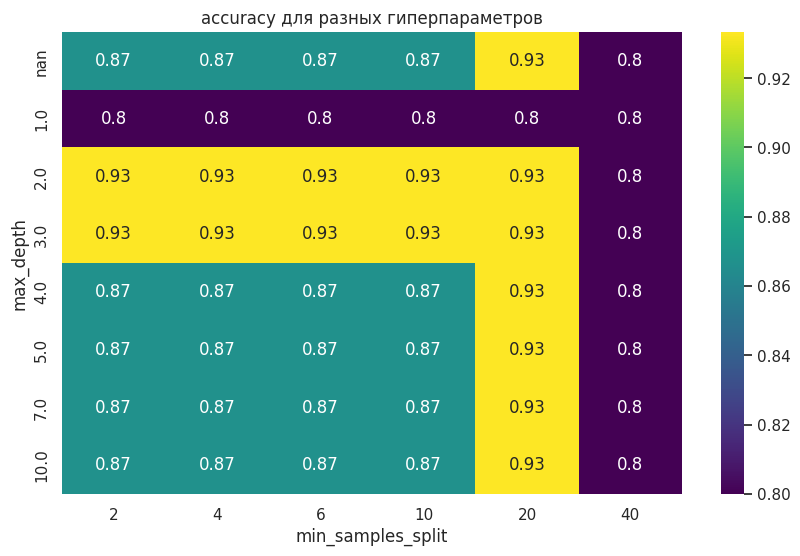

In [6]:
pivot = df.pivot(index="max_depth",
                 columns="min_samples_split",
                 values="test_acc")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("accuracy для разных гиперпараметров")
plt.xlabel("min_samples_split")
plt.ylabel("max_depth")
plt.show()

видим, что лучшие значения тестовой accuracy (0.93) достигаются при:

max_depth = {2, 3} и min_samples_split $\in$ {2, 4, 6, 10, 20}

То есть почти вся строка для глубин 2–3 (кроме min_samples_split=40) в оптимуме соотношения смещения и разброса.

Также столбец min_samples_split = 20 дает максимальное качество для любой max_depth, кроме 1.

### Решающие деревья своими руками

Итак, пришло время реализовать свой класс для обучения решающего дерева.

Реализую функцию `find_best_split` в модуле `decision_tree.py`.

Напомню, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности (критерий Джини) для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.

Загружаю датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Работаю с данными: создаю бинарный признак `pass`, равный единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выбираю пять числовых признаков, среди которых есть как очень информативные, так и потенциально неинформативные — коротко обосновываю свой выбор ниже.

Для каждого из выбранных признаков строю график зависимости критерия Джини от возможного порога разделения — все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализирую зависимость "значение признака - класс (0/1)" через scatter-график (с jitter и alpha) или `seaborn.stripplot`.

In [7]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [8]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
student_performance = fetch_ucirepo(id=320) 
  
# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets 

# variable information 
print(student_performance.variables) 

          name     role         type      demographic  \
0       school  Feature  Categorical             None   
1          sex  Feature       Binary              Sex   
2          age  Feature      Integer              Age   
3      address  Feature  Categorical             None   
4      famsize  Feature  Categorical            Other   
5      Pstatus  Feature  Categorical            Other   
6         Medu  Feature      Integer  Education Level   
7         Fedu  Feature      Integer  Education Level   
8         Mjob  Feature  Categorical       Occupation   
9         Fjob  Feature  Categorical       Occupation   
10      reason  Feature  Categorical             None   
11    guardian  Feature  Categorical             None   
12  traveltime  Feature      Integer             None   
13   studytime  Feature      Integer             None   
14    failures  Feature      Integer             None   
15   schoolsup  Feature       Binary             None   
16      famsup  Feature       B

In [9]:
df = pd.concat([X, y], axis=1)

df["pass"] = (df["G3"] >= 10).astype(int)

print("Размер данных:", df.shape)
df.head()

Размер данных: (649, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,1


Теперь функция для вычисления джини для всех порогов.
почти что find_best_split, только возвращает все значения.

In [10]:
def gini_for_thresholds(feature, target):
    order = np.argsort(feature)
    f_sorted = feature[order]
    y_sorted = target[order]

    thresholds = (f_sorted[:-1] + f_sorted[1:]) / 2
    mask = f_sorted[:-1] != f_sorted[1:]
    thresholds = thresholds[mask]

    classes = np.unique(target)

    left_counts = np.vstack([(y_sorted == c).cumsum() for c in classes]).T
    total_counts = left_counts[-1]

    right_counts = total_counts - left_counts

    left_total = np.arange(1, len(y_sorted) + 1)
    right_total = len(y_sorted) - left_total

    left_counts_masked = left_counts[:-1][mask]
    right_counts_masked = right_counts[:-1][mask]
    left_total_masked = left_total[:-1][mask]
    right_total_masked = right_total[:-1][mask]

    left_probs = left_counts_masked / left_total_masked[:, None]
    right_probs = right_counts_masked / right_total_masked[:, None]

    left_gini = 1 - (left_probs ** 2).sum(axis=1)
    right_gini = 1 - (right_probs ** 2).sum(axis=1)

    gini = -(left_total_masked / len(y_sorted)) * left_gini \
           -(right_total_masked / len(y_sorted)) * right_gini

    return thresholds, gini


In [11]:
selected_features = ["G1", "G2", "freetime", "failures", "absences"]

выбрал эти фичи, потому что:

G1 и G2 должны быть супер информативными, failures также даст информативное негативое влияние

А признаки freetime и особенно absences должны быть менее полезными (так как, например, свободное время после школы не особо влияет на итоговый балл).

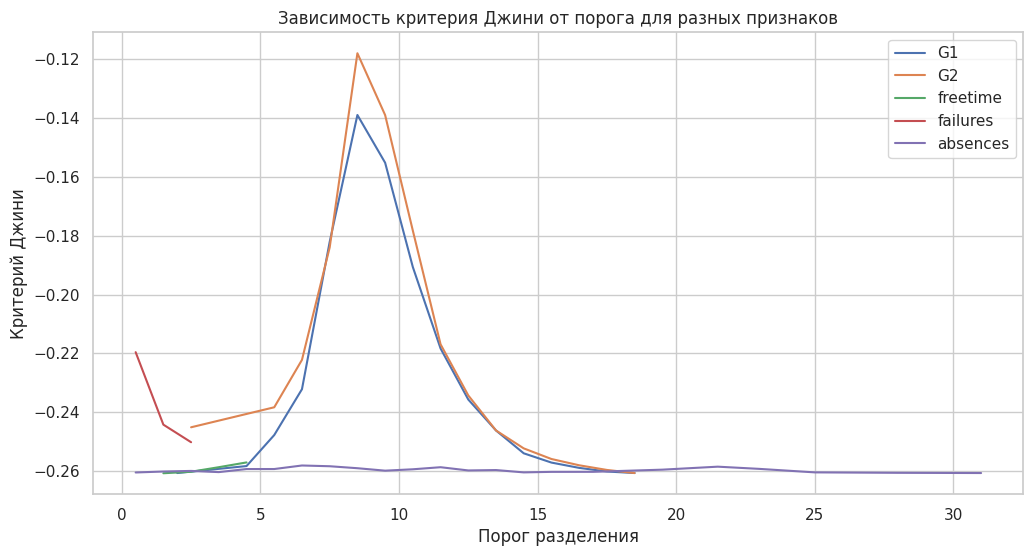

In [12]:
plt.figure(figsize=(12, 6))

for feature in selected_features:
    thresholds, gini_values = gini_for_thresholds(df[feature].values, df['pass'].values)
    plt.plot(thresholds, gini_values, label=feature)

plt.xlabel("Порог разделения")
plt.ylabel("Критерий Джини")
plt.title("Зависимость критерия Джини от порога для разных признаков")
plt.legend()
plt.show()

- G1 и G2

    Кривые Джини для этих признаков имеют выраженный пик около 8.
    Признаки очень информативные: существует порог, который хорошо разделяет классы pass=1 и pass=0.

- failures

    Кривая Джини отрицательная, но пик на малых значениях (около 1). Может из-за того, что студенты с большим числом неудач чаще не сдают экзамен. Не самый лучший признак


- freetime

    Кривая Джини практически плоская и низкая (около -0.26), признак слабый, почти не помогает разделять классы pass.

- absences

    Кривая очень плоская $\implies$ количество пропусков малополезно для прогнозирования сдачи экзамена

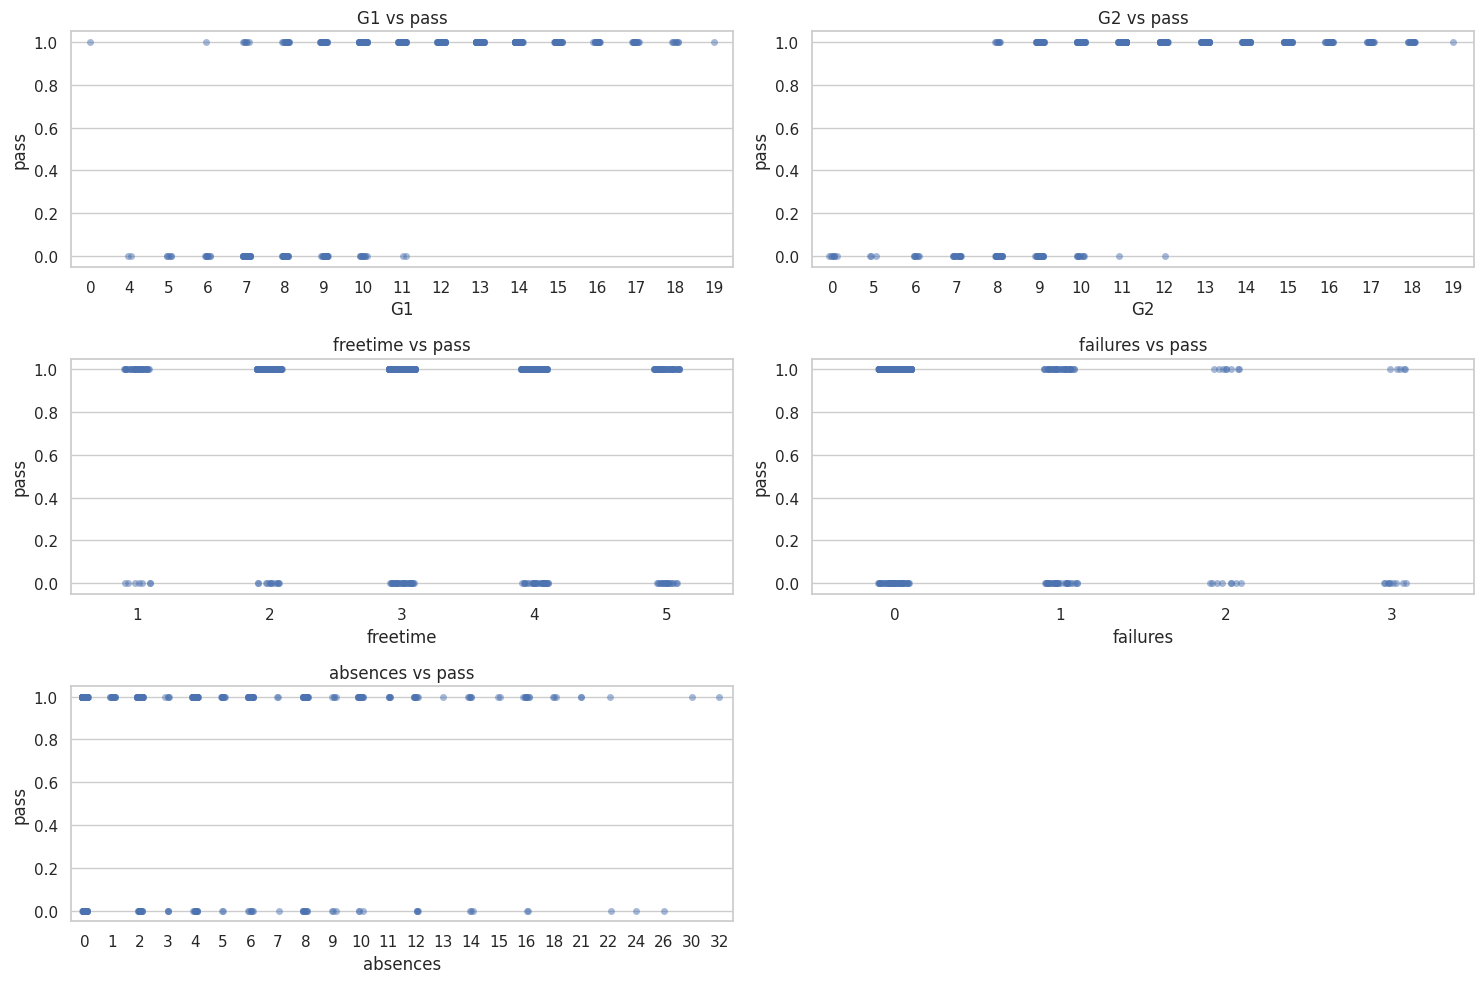

In [13]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features, 1):
    plt.subplot(3, 2, i)
    sns.stripplot(x=df[feature], y=df['pass'], jitter=0.1, alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("pass")
    plt.title(f"{feature} vs pass")

plt.tight_layout()
plt.show()

Ну тут также видим, что G1 и G2 хорошо помогают различать классы pass, а все остальные признаки просто вразнобой бьют.

На основании построенных графиков разбираюсь:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

#### 1. 
Наиболее информативными признаками являются G1 и G2. Кривые Джини для этих признаков имеют выраженный пик около 8, что означает, что существует чёткий порог, разделяющий классы pass=1 и pass=0. Root split логично делать по G2 или G1, потому что они дают наибольшую чистоту при разделении.

#### 2. 
Да, выводы совпадают: на scatter-графиках также видно, что точки классов pass=1 и pass=0 хорошо разделяются по G1 и G2. Остальные признаки не помогают разделять классы.

#### 3.
Для G1 и G2 кривые Джини имеют выраженный пик.

Для failures пик есть, но маленький и на низких значениях ~1, кривая менее крутая и информативность средняя.

Для freetime (очень короткая вообще) и absences кривые практически плоские и низкие, без пиков — деление по этим признакам не улучшает разделение классов.

Разбираюсь с уже написанным кодом в классе `DecisionTree` модуля `decision_tree.py`. Исправляю ошибки в методе `_fit_node`, а также реализую `_predict_node`.

В этом задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения производится по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (в конспекте — раздел «Учёт категориальных признаков»)

Здесь я после нахождения ошибок указал на них gpt и сказал переписать, исправив. потом правил то, что у него получилось, так как тесты не проходили.

Тестирую написанное решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого скачиваю таблицу agaricus-lepiota.data и применяю к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в этой таблице — целевая переменная ('e' — edible, 'p' — poisonous).

Обучаю решающее дерево на $50\%$ случайно выбранных объектов и получаю предсказания для оставшейся половины, вычисляю accuracy.

In [14]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
mushroom = fetch_ucirepo(id=73) 
  
# data (as pandas dataframes) 
X = mushroom.data.features 
y = mushroom.data.targets 

In [16]:
import sys
sys.path.append("/kaggle/input/hwcode5")

from decision_tree import DecisionTree
from sklearn.preprocessing import LabelEncoder


X = X.copy()
y = y.copy()

le_dict = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

le_target = LabelEncoder()
y = le_target.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(), y, test_size=0.5, random_state=42
)


feature_types = ["categorical"] * X_train.shape[1]
tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy on test set: {accuracy:.4f}")

Accuracy on test set: 1.0000


Реализую в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `DecisionTreeClassifier`.

Сравниваю реализованное дерево со стандартной имплементацией из `sklearn` для набора данных [nursery](https://archive.ics.uci.edu/dataset/76/nursery).

In [17]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
nursery = fetch_ucirepo(id=76) 
  
# data (as pandas dataframes) 
X = nursery.data.features 
y = nursery.data.targets 

In [18]:
X = X.copy()
y = y.copy()

le_dict = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

le_target = LabelEncoder()
y = le_target.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(), y, test_size=0.5, random_state=42
)

feature_types = ["categorical"] * X_train.shape[1]
tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)

y_pred_custom = tree.predict(X_test)

accuracy_custom = np.mean(y_pred_custom == y_test)
print(f"Custom DecisionTree accuracy: {accuracy_custom:.4f}")

Custom DecisionTree accuracy: 0.9920


In [19]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_sklearn = clf.predict(X_test)

accuracy_sklearn = np.mean(y_pred_sklearn == y_test)
print(f"Sklearn DecisionTreeClassifier accuracy: {accuracy_sklearn:.4f}")

Sklearn DecisionTreeClassifier accuracy: 0.9884


Качество почти одинаковое, разница всего ~0.004 (0.4%), $\implies$ моя реализация работает почти как sklearn и даже лучше.

## Bias-variance decomposition

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [19]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела использую одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволяет передавать их в общие функции.

### Вычисление bias и variance

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [20]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

33.46866903342311

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

Реализую описанный алгоритм. Если объект не вошел ни в одну из out-of-bag выборок, не учитываю его при вычислении итоговых величин. Использую только один цикл — по выборкам (от 0 до num_runs-1).

In [21]:
def compute_bias_variance(model, X, y, num_runs=1000, random_state=None):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    oob_predictions = [[] for _ in range(n_samples)]

    for run in range(num_runs):
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[indices]
        y_boot = y[indices]

        oob_mask = np.ones(n_samples, dtype=bool)
        oob_mask[indices] = False
        oob_indices = np.where(oob_mask)[0]

        if len(oob_indices) == 0:
            continue
            
        model.fit(X_boot, y_boot)

        y_pred_oob = model.predict(X[oob_indices])

        for idx, pred in zip(oob_indices, y_pred_oob):
            oob_predictions[idx].append(pred)

    bias_sq_sum = 0.0
    variance_sum = 0.0
    error_sum = 0.0
    count = 0

    for i in range(n_samples):
        preds = oob_predictions[i]
        if len(preds) == 0:
            continue
        preds = np.array(preds)
        mean_pred = preds.mean()

        bias_sq_sum += (mean_pred - y[i])**2
        variance_sum += ((preds - mean_pred)**2).mean()
        error_sum += ((preds - y[i])**2).mean()

        count += 1

    bias_sq = bias_sq_sum / count
    variance = variance_sum / count
    error = error_sum / count

    return bias_sq, variance, error

Оцениваю смещение, разброс и ошибку для трёх алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес — и смотрю, согласуются ли результаты с теорией.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
bias, var, err = compute_bias_variance(lr, X, y, num_runs=100)
print(f"LinearRegression: bias^2={bias:.4f}, variance={var:.4f}, error={err:.4f}")

dt = DecisionTreeRegressor(random_state=42)
bias, var, err = compute_bias_variance(dt, X, y, num_runs=100)
print(f"DecisionTreeRegressor: bias^2={bias:.4f}, variance={var:.4f}, error={err:.4f}")

rf = RandomForestRegressor(n_estimators=50, random_state=42)
bias, var, err = compute_bias_variance(rf, X, y, num_runs=50)
print(f"RandomForestRegressor: bias^2={bias:.4f}, variance={var:.4f}, error={err:.4f}")

LinearRegression: bias^2=0.5350, variance=0.0200, error=0.5549
DecisionTreeRegressor: bias^2=0.2506, variance=0.2959, error=0.5465
RandomForestRegressor: bias^2=0.2473, variance=0.0208, error=0.2681


результаты соответствуют теории.


1. Linear Regression

Высокое смещение и очень низкий разброс.

Это полностью соответствует теории.

2. Decision Tree

Смещение значительно ниже, чем у линейной регрессии.
Разброс при этом высокий.
В итоге ошибка похожа на линейную регрессию, но распределена по-другому.

Это тоже согласуется с теорией:
деревья - модели с низким смещением, но высоким разбросом.

3. Random Forest

Смещение почти такое же, как у дерева, но при этом разброс очень маленький.
Итоговая ошибка — самая маленькая из всех, почти в 2 раза меньше, чем у линейной модели.

Все как должно быть, Random Forest показывает наилучшую итоговую ошибку, уменьшая variance деревьев без увеличения bias.

### Визуализация предсказаний базовых алгоритмов бэггинга

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

Реализую функцию `plot_predictions`, которая выполняет следующие шаги:

1. Выбор подмножества данных. Случайным образом выбираются `num_test_objects` пар «объект-целевая переменная» из исходных данных X, y — они образуют тестовую выборку X_test, y_test, остальные идут в обучающую выборку X_train, y_train.

2. Метод бутстрапа. Генерирую методом бутстрапа `num_runs` новых выборок из X_train, y_train, на каждой обучаю алгоритм и делаю предсказания для объектов X_test.

3. Построение графика. Рисую scatter-график: по оси абсцисс — номера тестовых объектов от 0 до num_test_objects - 1, по оси ординат — предсказания моделей на этих объектах. Получается num_test_objects вертикальных столбиков из точек — по num_runs предсказаний на каждый тестовый объект.

   Для каждого тестового объекта все предсказания отмечены одним цветом (виден столбик), а истинный ответ y_test — чёрной точкой. Оси подписаны, добавлен заголовок графика.

In [23]:
def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title=""):
    n = len(X)
    indices = np.random.choice(n, size=num_test_objects, replace=False)
    
    X_test = X[indices]
    y_test = y[indices]

    mask = np.ones(n, dtype=bool)
    mask[indices] = False
    X_train = X[mask]
    y_train = y[mask]

    all_preds = np.zeros((num_runs, num_test_objects))

    for i in range(num_runs):
        bootstrap_idx = np.random.choice(len(X_train), size=len(X_train), replace=True)

        X_bs = X_train[bootstrap_idx]
        y_bs = y_train[bootstrap_idx]

        m = clone(model)
        m.fit(X_bs, y_bs)

        all_preds[i] = m.predict(X_test)

    plt.figure(figsize=(14, 6))

    for j in range(num_test_objects):
        xs = np.full(num_runs, j)
        plt.scatter(xs, all_preds[:, j], alpha=0.4, s=15)

    plt.scatter(np.arange(num_test_objects), y_test, 
                color="black", s=80, label="True values")

    plt.title(title, fontsize=16)
    plt.xlabel("Test object index", fontsize=14)
    plt.ylabel("Predictions", fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

Рисую графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат — это помогает корректно сравнить масштаб разброса у каждого из алгоритмов. Для каждого комментирую, как он характеризует смещение и разброс.

In [30]:
def plot_three_models(X, y, num_runs=100, num_test_objects=10):
    models = [
        ("Linear Regression", LinearRegression()),
        ("Decision Tree", DecisionTreeRegressor()),
        ("Random Forest", RandomForestRegressor())
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    for ax, (title, model) in zip(axes, models):

        X = np.array(X)
        y = np.array(y)

        idx = np.random.choice(len(X), size=num_test_objects, replace=False)
        X_test = X[idx]
        y_test = y[idx]

        mask = np.ones(len(X), dtype=bool)
        mask[idx] = False
        X_train = X[mask]
        y_train = y[mask]

        all_preds = np.zeros((num_runs, num_test_objects))

        for run in range(num_runs):
            bootstrap_idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
            X_bs = X_train[bootstrap_idx]
            y_bs = y_train[bootstrap_idx]

            m = clone(model)
            m.fit(X_bs, y_bs)
            all_preds[run] = m.predict(X_test)

        for i in range(num_test_objects):
            ax.scatter(
                np.full(num_runs, i),
                all_preds[:, i],
                alpha=0.5,
            )
            ax.scatter(i, y_test[i], color="black", s=60)

        ax.set_title(title)
        ax.set_xlabel("Test object index")
        ax.grid(True)

    axes[0].set_ylabel("Predictions")
    plt.tight_layout()
    plt.show()

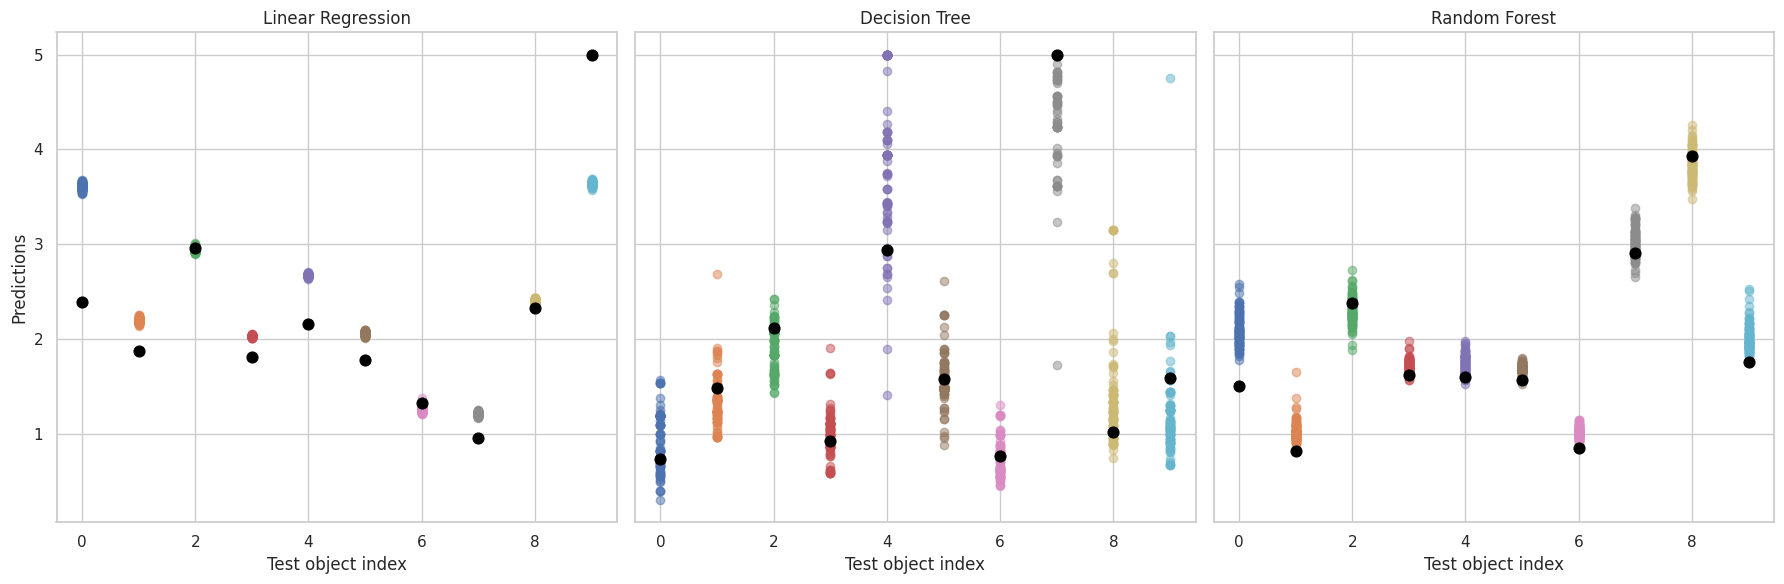

In [31]:
plot_three_models(X, y, num_runs=100, num_test_objects=10)

1. Linear Regression

Точки почти не размазаны по вертикали $\implies$ низкий разброс 

Но они часто смещены от чёрной точки $\implies$ высокий bias, модель недоучивает нелинейности.

2. Decision Tree

Столбики очень высокие $\implies$ огромный разброс предсказаний

Смещение при этом не очень высокое.

3. Random Forest

Столбики плотные, разброс сильно меньше, чем у дерева.

Но смещение остаётся примерно как у дерева - низкий.